In [15]:
import pandas as pd

In [16]:
stats_df=pd.read_csv("../data/processed/abd_vs_bowlers_overall.csv")
phase_stats_df=pd.read_csv("../data/processed/abd_vs_bowler_phase-wise.csv")

In [17]:
stats_df.shape


(7, 10)

In [18]:
stats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bowler         7 non-null      str    
 1   batsman_run    7 non-null      int64  
 2   is_legal_ball  7 non-null      int64  
 3   dot_ball       7 non-null      int64  
 4   is_dismissal   7 non-null      int64  
 5   4s             7 non-null      int64  
 6   6s             7 non-null      int64  
 7   strike_rate    7 non-null      float64
 8   dot_ball%      7 non-null      float64
 9   batting_avg    7 non-null      float64
dtypes: float64(3), int64(6), str(1)
memory usage: 692.0 bytes


In [19]:
phase_stats_df.shape

(21, 12)

In [20]:
phase_stats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bowler         21 non-null     str    
 1   phase          21 non-null     str    
 2   batsman_run    21 non-null     int64  
 3   is_legal_ball  21 non-null     int64  
 4   dot_ball       21 non-null     int64  
 5   is_dismissal   21 non-null     int64  
 6   is_boundary    21 non-null     int64  
 7   4s             21 non-null     int64  
 8   6s             21 non-null     int64  
 9   strike_rate    21 non-null     float64
 10  dot_ball_pct   21 non-null     float64
 11  boundary_pct   21 non-null     float64
dtypes: float64(3), int64(7), str(2)
memory usage: 2.1 KB


#### we have loaded and inspected our df for sanity

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns



##### first plotting for overall stats

In [22]:
# plotting SR VS BOWLER

sorted_stats_df=stats_df.sort_values(by='strike_rate',ascending=False)

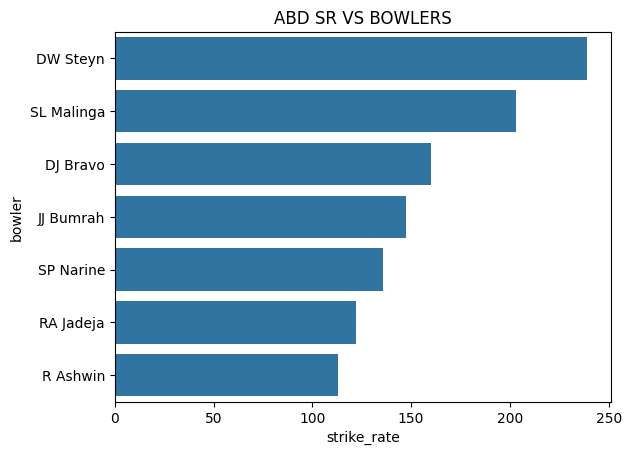

In [23]:
sns.barplot(data=sorted_stats_df,x='strike_rate',y='bowler')
plt.title("ABD SR VS BOWLERS")
plt.show()

In [24]:
# plotting dotball %
sorted_stats_df=stats_df.sort_values(by='dot_ball%',ascending=False)

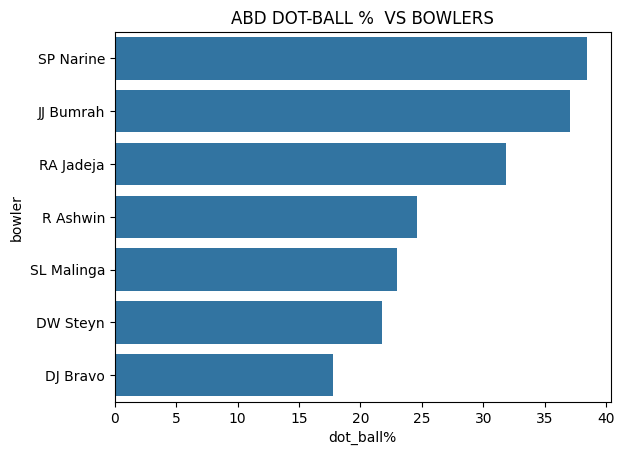

In [25]:
sns.barplot(data=sorted_stats_df,x='dot_ball%',y='bowler')
plt.title("ABD DOT-BALL %  VS BOWLERS")
plt.show()

In [26]:
stats_df.columns

Index(['bowler', 'batsman_run', 'is_legal_ball', 'dot_ball', 'is_dismissal',
       '4s', '6s', 'strike_rate', 'dot_ball%', 'batting_avg'],
      dtype='str')

#### Plotting for PHASE-WISE STATS

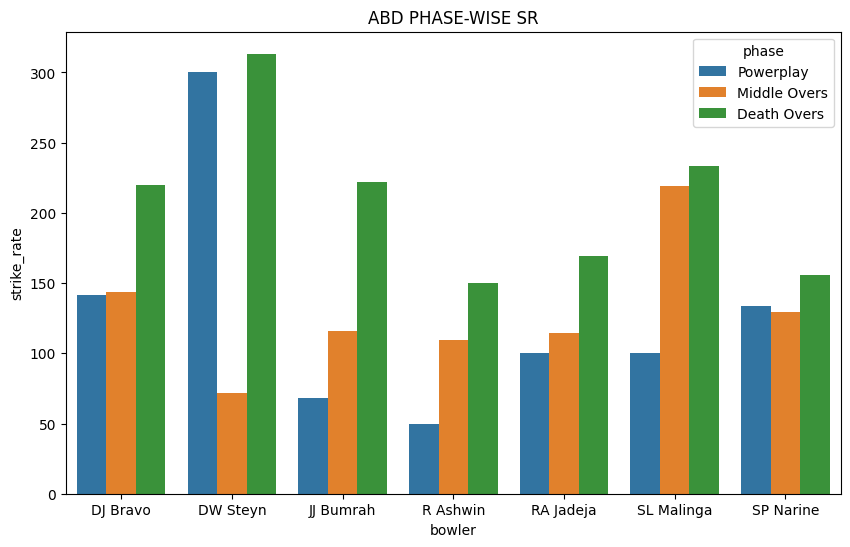

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=phase_stats_df,x='bowler',y='strike_rate',hue='phase',
hue_order=['Powerplay','Middle Overs','Death Overs'])
plt.title("ABD PHASE-WISE SR")
plt.show()


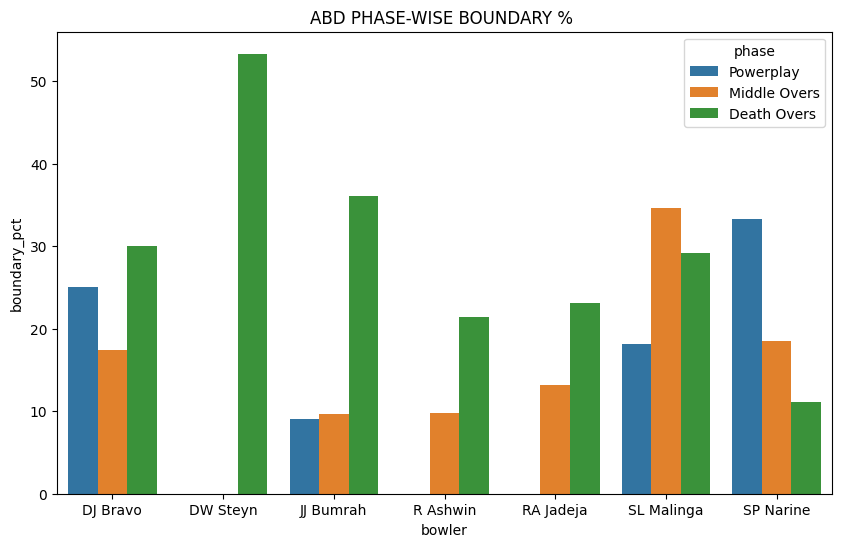

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=phase_stats_df,x='bowler',y='boundary_pct',hue='phase',
hue_order=['Powerplay','Middle Overs','Death Overs'])
plt.title("ABD PHASE-WISE BOUNDARY % ")
plt.show()


#### ADVANCED ANALYSIS 
#### *COMPARING WITH RELATIVE METRICS*

In [29]:
df=pd.read_csv("../data/raw/IPL_Ball_by_Ball_2008_2022.csv")

In [30]:
bowlers=[
    "JJ Bumrah",
    "DJ Bravo",
    "DW Steyn",
    "SL Malinga",
    "R Ashwin",
    "RA Jadeja",
    "SP Narine"

]

In [31]:
filtered_df=df[
    (df['batter']!='AB de Villiers') &
    (df['bowler'].isin(bowlers))
]
filtered_df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
189,1312200,2,11,1,HH Pandya,R Ashwin,Shubman Gill,NaN,1,0,1,0,0,NaN,NaN,NaN,Gujarat Titans
190,1312200,2,11,2,Shubman Gill,R Ashwin,HH Pandya,NaN,1,0,1,0,0,NaN,NaN,NaN,Gujarat Titans
191,1312200,2,11,3,HH Pandya,R Ashwin,Shubman Gill,NaN,4,0,4,0,0,NaN,NaN,NaN,Gujarat Titans
192,1312200,2,11,4,HH Pandya,R Ashwin,Shubman Gill,NaN,6,0,6,0,0,NaN,NaN,NaN,Gujarat Titans
193,1312200,2,11,5,HH Pandya,R Ashwin,Shubman Gill,NaN,1,0,1,0,0,NaN,NaN,NaN,Gujarat Titans


In [32]:
filtered_df.shape

(21793, 17)

In [33]:
filtered_df['bowler'].unique()

<StringArray>
[  'R Ashwin',  'JJ Bumrah',  'SP Narine',   'DJ Bravo',  'RA Jadeja',
   'DW Steyn', 'SL Malinga']
Length: 7, dtype: str

In [34]:
filtered_df['batter'].str.contains('Villiers').any()

np.False_

In [35]:
# creating phases
def classify_phase(over):
    if 0<=over<=5:
        return 'Powerplay'
    elif 6<=over<=14:
        return 'Middle Overs'
    elif  15<=over <=19:
        return 'Death Overs'
    else:
        return "Unknown"

filtered_df['phase']=filtered_df['overs'].apply(classify_phase)

In [36]:
filtered_df.columns

Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam', 'phase'],
      dtype='str')

In [37]:
# dot balls

filtered_df['dot_ball']=(filtered_df['total_run']==0).astype(int)

In [38]:
# legal balls
filtered_df['legal_ball']=(~filtered_df['extra_type'].isin(['wides'])).astype(int)

In [39]:
filtered_df['boundaries']=((filtered_df['batsman_run']==4) | (filtered_df['batsman_run']==6)).astype(int)

In [40]:
overall_df=filtered_df.groupby('bowler').agg({
    'batsman_run':'sum',
    'legal_ball':'sum',
    'dot_ball':'sum',
    'boundaries':'sum'
}).reset_index()

In [41]:
overall_df.head()

,bowler,batsman_run,legal_ball,dot_ball,boundaries
0,DJ Bravo,4106,3084,990,494
1,DW Steyn,2351,2166,1014,331
2,JJ Bumrah,3167,2704,1051,391
3,R Ashwin,4318,3843,1362,435
4,RA Jadeja,3880,3118,1008,407


In [42]:
# deriving SR ,DOT-BALL % AND BOUNDARY %
overall_df['strike_rate']=((overall_df['batsman_run']/overall_df['legal_ball'])*100).round(2)

In [43]:
overall_df['dot-ball%']=(overall_df['dot_ball']/overall_df['legal_ball']*100).round(2)
overall_df['Boundary%']=(overall_df['boundaries']/overall_df['legal_ball']*100).round(2)

In [44]:
overall_df.head(7)

,bowler,batsman_run,legal_ball,dot_ball,boundaries,strike_rate,dot-ball%,Boundary%
0,DJ Bravo,4106,3084,990,494,133.14,32.10,16.02
1,DW Steyn,2351,2166,1014,331,108.54,46.81,15.28
2,JJ Bumrah,3167,2704,1051,391,117.12,38.87,14.46
3,R Ashwin,4318,3843,1362,435,112.36,35.44,11.32
4,RA Jadeja,3880,3118,1008,407,124.44,32.33,13.05
5,SL Malinga,3070,2785,1130,382,110.23,40.57,13.72
6,SP Narine,3702,3428,1348,391,107.99,39.32,11.41


In [45]:
overall_df.drop(columns=['boundaries'])

,bowler,batsman_run,legal_ball,dot_ball,strike_rate,dot-ball%,Boundary%
0,DJ Bravo,4106,3084,990,133.14,32.10,16.02
1,DW Steyn,2351,2166,1014,108.54,46.81,15.28
2,JJ Bumrah,3167,2704,1051,117.12,38.87,14.46
3,R Ashwin,4318,3843,1362,112.36,35.44,11.32
4,RA Jadeja,3880,3118,1008,124.44,32.33,13.05
5,SL Malinga,3070,2785,1130,110.23,40.57,13.72
6,SP Narine,3702,3428,1348,107.99,39.32,11.41


In [46]:
# now phase-wise metrics

phase_wise_df=filtered_df.groupby(['bowler','phase']).agg({
    'batsman_run':'sum',
    'legal_ball':'sum',
    'dot_ball':'sum',
    'boundaries':'sum'
}).reset_index()

In [47]:
phase_wise_df.head(7)

,bowler,phase,batsman_run,legal_ball,dot_ball,boundaries
0,DJ Bravo,Death Overs,2058,1381,397,252
1,DJ Bravo,Middle Overs,1781,1486,486,200
2,DJ Bravo,Powerplay,267,217,107,42
3,DW Steyn,Death Overs,799,622,216,100
4,DW Steyn,Middle Overs,424,401,174,55
5,DW Steyn,Powerplay,1128,1143,624,176
6,JJ Bumrah,Death Overs,1483,1127,343,168


In [48]:
# deriving SR ,DOT-BALL % AND BOUNDARY%
phase_wise_df['strike_rate']=((phase_wise_df['batsman_run']/phase_wise_df['legal_ball'])*100).round(2)
phase_wise_df['dot-ball%']=((phase_wise_df['dot_ball']/phase_wise_df['legal_ball'])*100).round(2)
phase_wise_df['Boundary%']=((phase_wise_df['boundaries']/phase_wise_df['legal_ball'])*100).round(2)

In [49]:
phase_wise_df.drop(columns=['boundaries'])

,bowler,phase,batsman_run,legal_ball,dot_ball,strike_rate,dot-ball%,Boundary%
0,DJ Bravo,Death Overs,2058,1381,397,149.02,28.75,18.25
1,DJ Bravo,Middle Overs,1781,1486,486,119.85,32.71,13.46
2,DJ Bravo,Powerplay,267,217,107,123.04,49.31,19.35
3,DW Steyn,Death Overs,799,622,216,128.46,34.73,16.08
4,DW Steyn,Middle Overs,424,401,174,105.74,43.39,13.72
5,DW Steyn,Powerplay,1128,1143,624,98.69,54.59,15.40
6,JJ Bumrah,Death Overs,1483,1127,343,131.59,30.43,14.91
7,JJ Bumrah,Middle Overs,708,663,254,106.79,38.31,11.76
8,JJ Bumrah,Powerplay,976,914,454,106.78,49.67,15.86
9,R Ashwin,Death Overs,635,510,158,124.51,30.98,11.57


In [50]:
overall_df.to_csv("../data/processed/bowlers_overall_stats.csv")

In [51]:
phase_wise_df.to_csv("../data/processed/bowlers_overall_phasewise_stats.csv")

#### Merging abd stats with baseline stats for relative comparision

In [52]:
overall_abd_df=pd.read_csv("../data/processed/abd_vs_bowlers_overall.csv")

In [53]:
overall_relative_df=pd.merge(overall_abd_df,overall_df,on='bowler',suffixes=('__abd','__baseline'))
overall_relative_df

,bowler,batsman_run__abd,is_legal_ball,dot_ball__abd,is_dismissal,4s,6s,strike_rate__abd,dot_ball%,batting_avg,batsman_run__baseline,legal_ball,dot_ball__baseline,boundaries,strike_rate__baseline,dot-ball%,Boundary%
0,DJ Bravo,72,45,8,1,8,2,160.00,17.78,72.00,4106,3084,990,494,133.14,32.10,16.02
1,DW Steyn,55,23,5,1,3,5,239.13,21.74,55.00,2351,2166,1014,331,108.54,46.81,15.28
2,JJ Bumrah,131,89,33,3,10,8,147.19,37.08,43.67,3167,2704,1051,391,117.12,38.87,14.46
3,R Ashwin,69,61,15,2,5,2,113.11,24.59,34.50,4318,3843,1362,435,112.36,35.44,11.32
4,RA Jadeja,111,91,29,2,8,5,121.98,31.87,55.50,3880,3118,1008,407,124.44,32.33,13.05
5,SL Malinga,124,61,14,0,10,8,203.28,22.95,inf,3070,2785,1130,382,110.23,40.57,13.72
6,SP Narine,53,39,15,4,5,2,135.90,38.46,13.25,3702,3428,1348,391,107.99,39.32,11.41


In [54]:
overall_relative_df.columns

Index(['bowler', 'batsman_run__abd', 'is_legal_ball', 'dot_ball__abd',
       'is_dismissal', '4s', '6s', 'strike_rate__abd', 'dot_ball%',
       'batting_avg', 'batsman_run__baseline', 'legal_ball',
       'dot_ball__baseline', 'boundaries', 'strike_rate__baseline',
       'dot-ball%', 'Boundary%'],
      dtype='str')

#### This is too mesy and contains too many columns creating confusion

In [55]:
# renaming some columns for consistency as some columns had different names in our 2 dataframes

overall_relative_df=overall_relative_df.rename(columns={
    'dot-ball%':'dot-ball%_baseline',
    'Boundary%':'Boundary%_baseline'
})

In [56]:
overall_relative_df.columns

Index(['bowler', 'batsman_run__abd', 'is_legal_ball', 'dot_ball__abd',
       'is_dismissal', '4s', '6s', 'strike_rate__abd', 'dot_ball%',
       'batting_avg', 'batsman_run__baseline', 'legal_ball',
       'dot_ball__baseline', 'boundaries', 'strike_rate__baseline',
       'dot-ball%_baseline', 'Boundary%_baseline'],
      dtype='str')

In [57]:
# we did some wrong re-naming so will have to correct it 
# we renamed dot-ball% to abd but its basline dotball %

overall_abd_df = overall_abd_df.rename(columns={
    'dot-ball%': 'dot-ball%_abd',
    'Boundary%': 'Boundary%_abd'
})

In [58]:
overall_df = overall_df.rename(columns={
    'dot-ball%': 'dot-ball%_baseline',
    'Boundary%': 'Boundary%_baseline'
})


In [59]:
# recreting the merge so no more confusion
overall_relative_df = pd.merge(
    overall_abd_df,
    overall_df,
    on='bowler',
    suffixes=('_abd', '_baseline')
)

In [60]:
overall_relative_df.columns

Index(['bowler', 'batsman_run_abd', 'is_legal_ball', 'dot_ball_abd',
       'is_dismissal', '4s', '6s', 'strike_rate_abd', 'dot_ball%',
       'batting_avg', 'batsman_run_baseline', 'legal_ball',
       'dot_ball_baseline', 'boundaries', 'strike_rate_baseline',
       'dot-ball%_baseline', 'Boundary%_baseline'],
      dtype='str')

In [61]:
overall_relative_cleaned_df = overall_relative_df[[
    ''
    'bowler',
    'strike_rate_abd',
    'strike_rate_baseline',
    'dot_ball%',
    'dot-ball%_baseline',
    
    
]]
overall_relative_cleaned_df

,bowler,strike_rate_abd,strike_rate_baseline,dot_ball%,dot-ball%_baseline
0,DJ Bravo,160.00,133.14,17.78,32.10
1,DW Steyn,239.13,108.54,21.74,46.81
2,JJ Bumrah,147.19,117.12,37.08,38.87
3,R Ashwin,113.11,112.36,24.59,35.44
4,RA Jadeja,121.98,124.44,31.87,32.33
5,SL Malinga,203.28,110.23,22.95,40.57
6,SP Narine,135.90,107.99,38.46,39.32


#### Now deriving Phase-wise relative metrics

In [62]:
# phase-wise relative metrics
phase_wise_abd_df=pd.read_csv("../data/processed/abd_vs_bowler_phase-wise.csv")

In [63]:
phase_wise_abd_df.columns

Index(['bowler', 'phase', 'batsman_run', 'is_legal_ball', 'dot_ball',
       'is_dismissal', 'is_boundary', '4s', '6s', 'strike_rate',
       'dot_ball_pct', 'boundary_pct'],
      dtype='str')

In [64]:
phase_wise_df.columns

Index(['bowler', 'phase', 'batsman_run', 'legal_ball', 'dot_ball',
       'boundaries', 'strike_rate', 'dot-ball%', 'Boundary%'],
      dtype='str')

In [65]:
phase_wise_abd_df=phase_wise_abd_df.rename(columns={
    'dot_ball_pct':'dot-ball%',
    'boundary_pct':'Boundary%'
})
phase_wise_abd_df.columns

Index(['bowler', 'phase', 'batsman_run', 'is_legal_ball', 'dot_ball',
       'is_dismissal', 'is_boundary', '4s', '6s', 'strike_rate', 'dot-ball%',
       'Boundary%'],
      dtype='str')

In [66]:
# now merging 
phase_wise_relative_df=pd.merge(
    phase_wise_abd_df,
    phase_wise_df,
    on=['bowler','phase'],
    suffixes=('_abd','_baseline')
)

In [67]:
phase_wise_relative_df.columns

Index(['bowler', 'phase', 'batsman_run_abd', 'is_legal_ball', 'dot_ball_abd',
       'is_dismissal', 'is_boundary', '4s', '6s', 'strike_rate_abd',
       'dot-ball%_abd', 'Boundary%_abd', 'batsman_run_baseline', 'legal_ball',
       'dot_ball_baseline', 'boundaries', 'strike_rate_baseline',
       'dot-ball%_baseline', 'Boundary%_baseline'],
      dtype='str')

In [68]:
relative_phase_wise_df=phase_wise_relative_df[[
    'phase',
    'bowler',
    'strike_rate_abd',
    'strike_rate_baseline',
    'Boundary%_abd',
    'Boundary%_baseline']]
relative_phase_wise_df

,phase,bowler,strike_rate_abd,strike_rate_baseline,Boundary%_abd,Boundary%_baseline
0,Death Overs,DJ Bravo,220.00,149.02,30.00,18.25
1,Middle Overs,DJ Bravo,143.48,119.85,17.39,13.46
2,Powerplay,DJ Bravo,141.67,123.04,25.00,19.35
3,Death Overs,DW Steyn,313.33,128.46,53.33,16.08
4,Middle Overs,DW Steyn,71.43,105.74,0.00,13.72
5,Powerplay,DW Steyn,300.00,98.69,0.00,15.40
6,Death Overs,JJ Bumrah,222.22,131.59,36.11,14.91
7,Middle Overs,JJ Bumrah,116.13,106.79,9.68,11.76
8,Powerplay,JJ Bumrah,68.18,106.78,9.09,15.86
9,Death Overs,R Ashwin,150.00,124.51,21.43,11.57


In [70]:
overall_relative_cleaned_df.to_csv("../data/processed/overall_realtive_metrics.csv",index=False)

In [71]:
relative_phase_wise_df.to_csv("../data/processed/phase_wise_realtive_metrics.csv",index=False)